## Importing ***PySpark***

In [1]:
# importing pyspark
from pyspark.sql import SparkSession 

### Spark session started

In [2]:
spark = (
    SparkSession.builder
    .appName("Test")
    .config("spark.master", "local[*]")
    .getOrCreate()
)

print("Spark Session Created")

Spark Session Created


## **Module 1**: Data Loading & Schema Handling
#### Task 1: Load all CSV files into PySpark DataFrames


In [3]:
# country_wise_latest.csv
df_country_wise_latest = spark.read.csv(
    "archive/country_wise_latest.csv",
    header = True,
    inferSchema = True
)

# covid_19_clean_complete.csv
df_covid_19_clean_complete = spark.read.csv(
    "archive/covid_19_clean_complete.csv",
    header = True,
    inferSchema = True
)

# day_wise.csv
df_day_wise = spark.read.csv(
    "archive/day_wise.csv",
    header = True,
    inferSchema = True
)

# fully_grouped.csv
df_full_grouped = spark.read.csv(
    "archive/full_grouped.csv",
    header = True,
    inferSchema = True
)

# usa_county_wise.csv
df_usa_county_wise = spark.read.csv(
    "archive/usa_county_wise.csv",
    header = True,
    inferSchema = True
)

# worldometer_data.csv
df_worldometer_data = spark.read.csv(
    "archive/worldometer_data.csv",
    header = True,
    inferSchema = True
)


#### Diplaying the dataframes

In [4]:
# country_wise_latest.csv
print("\ncountry_wise_latest.csv","\n")
print(df_country_wise_latest.show(5))

# covid_19_clean_complete.csv
print("-"*90,"\ncovid_19_clean_complete.csv\n")
print(df_covid_19_clean_complete.show(5))

# day_wise.csv
print("-"*90,"\nday_wise.csv\n")
print(df_day_wise.show(5))

# full_grouped.csv
print("-"*90,"\nfull_grouped.csv\n")
print(df_full_grouped.show(5))

# usa_county_wise.csv
print("-"*90,"\nusa_county_wise.csv\n")
print(df_usa_county_wise.show(5))

# worldometer_data.csv
print("-"*90,"\nworldometer_data.csv\n")
print(df_worldometer_data.show(5))



country_wise_latest.csv 

+--------------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+-------------------+-------------+-----------------+--------------------+
|Country/Region|Confirmed|Deaths|Recovered|Active|New cases|New deaths|New recovered|Deaths / 100 Cases|Recovered / 100 Cases|Deaths / 100 Recovered|Confirmed last week|1 week change|1 week % increase|          WHO Region|
+--------------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+-------------------+-------------+-----------------+--------------------+
|   Afghanistan|    36263|  1269|    25198|  9796|      106|        10|           18|               3.5|                69.49|                  5.04|              35526|          737|             2.07|Eastern Mediterra...|
|       Albania|     4880|   144|     2745|  1991|      117|         6|          

#### Displaying Schemas

In [5]:
# country_wise_latest.csv
print("\ncountry_wise_latest.csv","\n")
df_country_wise_latest.printSchema()

# covid_19_clean_complete.csv
print("-"*90,"\ncovid_19_clean_complete.csv\n")
df_covid_19_clean_complete.printSchema()

# day_wise.csv
print("-"*90,"\nday_wise.csv\n")
df_day_wise.printSchema()

# full_grouped.csv
print("-"*90,"\nfull_grouped.csv\n")
df_full_grouped.printSchema()

# usa_county_wise.csv
print("-"*90,"\nusa_county_wise.csv\n")
df_usa_county_wise.printSchema()

# worldometer_data.csv
print("-"*90,"\nworldometer_data.csv\n")
df_worldometer_data.printSchema()


country_wise_latest.csv 

root
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- Deaths / 100 Cases: double (nullable = true)
 |-- Recovered / 100 Cases: double (nullable = true)
 |-- Deaths / 100 Recovered: string (nullable = true)
 |-- Confirmed last week: integer (nullable = true)
 |-- 1 week change: integer (nullable = true)
 |-- 1 week % increase: double (nullable = true)
 |-- WHO Region: string (nullable = true)

------------------------------------------------------------------------------------------ 
covid_19_clean_complete.csv

root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable =

#### Displaying Row Count

In [6]:
# country_wise_latest.csv
print(f"{'country_wise_latest.csv':<30} : {df_country_wise_latest.count():>10}")

# covid_19_clean_complete.csv
print(f"{'covid_19_clean_complete.csv':<30} : {df_covid_19_clean_complete.count():>10}")

# day_wise.csv
print(f"{'day_wise.csv' :<30} : {df_day_wise.count() :>10}")

# full_grouped.csv
print(f"{'full_grouped.csv' :<30} : {df_full_grouped.count():>10}")

# usa_county_wise.csv
print(f"{'usa_county_wise.csv':<30} : {df_usa_county_wise.count() :>10}")

# worldometer_data.csv
print(f"{'worldometer_data.csv':<30} : {df_worldometer_data.count():>10}")




country_wise_latest.csv        :        187
covid_19_clean_complete.csv    :      49068
day_wise.csv                   :        188
full_grouped.csv               :      35156
usa_county_wise.csv            :     627920
worldometer_data.csv           :        209


## **Module 2** : Data Cleaning Tasks

#### **Task 2** : Handle Missing Province/State Values


In [7]:
from pyspark.sql.functions import*

In [8]:
# Checking null values in Province/State column
df_null_province = df_covid_19_clean_complete.filter(col("Province/State").isNull())

# Country-wise NULL count report
country_null_report = (
    df_covid_19_clean_complete
    .filter(col("Province/State").isNull())
    .groupBy("Country/Region")
    .count()
    .withColumnRenamed("count", "Null Province Count")
    .orderBy(desc("Null Province Count"))
)

# Replace NULL Province/State values with "Unknown"
df_covid_19_clean_complete = df_covid_19_clean_complete.fillna({"Province/State": "Unknown"})

print("Cleaned data")
df_covid_19_clean_complete.filter(col("Province/State") == "Unknown").show(10, truncate=False)

Cleaned data
+--------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Province/State|Country/Region     |Lat     |Long     |Date      |Confirmed|Deaths|Recovered|Active|WHO Region           |
+--------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Unknown       |Afghanistan        |33.93911|67.709953|2020-01-22|0        |0     |0        |0     |Eastern Mediterranean|
|Unknown       |Albania            |41.1533 |20.1683  |2020-01-22|0        |0     |0        |0     |Europe               |
|Unknown       |Algeria            |28.0339 |1.6596   |2020-01-22|0        |0     |0        |0     |Africa               |
|Unknown       |Andorra            |42.5063 |1.5218   |2020-01-22|0        |0     |0        |0     |Europe               |
|Unknown       |Angola             |-11.2027|17.8739  |2020-01-22|0        |0     |0        |0     |Africa               |
|Un

#### **Task 3** : Standardize Country Names

In [9]:
# Step 1 : Find Country Name Inconsistencies

# Get distinct country names from all datasets
full_countries = df_full_grouped.select("Country/Region").distinct()
latest_countries = df_country_wise_latest.select("Country/Region").distinct()
worldometer_countries = df_worldometer_data.select("Country/Region").distinct()

# Countries present in full_grouped but NOT present in country_wise_latest
full_countries.subtract(
    latest_countries
).show(truncate=False)

# Countries present in worldometer_data but NOT present in full_grouped
worldometer_countries.subtract(
    full_countries
).show(truncate=False)


# Step 2 : Define Standardization Rules
country_mappings = {
    "US": "USA",
    "S. Korea": "South Korea",
    "UK": "United Kingdom",
    "UAE": "United Arab Emirates",
    "Taiwan*": "Taiwan",
    "Korea, South": "South Korea"
}

# Step 3 : Function to Standardize Country Names
def standardize_country_names(df):
    # Remove extra spaces from beginning/end
    df = df.withColumn(
        "Country/Region",
        regexp_replace(
            col("Country/Region"),
            "^\\s+|\\s+$",
            ""
        )
    )

    # Apply standardization rules
    country_column = col("Country/Region")
    for old_name, new_name in country_mappings.items():
        country_column = when(
            country_column == old_name,
            new_name
        ).otherwise(country_column)

    # Update column
    df = df.withColumn(
        "Country/Region",
        country_column
    )
    return df


# Step 4 : Apply Standardization
df_full_grouped = standardize_country_names(df_full_grouped)
df_country_wise_latest = standardize_country_names(df_country_wise_latest)
df_worldometer_data = standardize_country_names(df_worldometer_data)

+--------------+
|Country/Region|
+--------------+
+--------------+

+----------------------+
|Country/Region        |
+----------------------+
|Macao                 |
|CAR                   |
|Turks and Caicos      |
|Ivory Coast           |
|Montserrat            |
|Taiwan                |
|Caribbean Netherlands |
|New Caledonia         |
|Myanmar               |
|Martinique            |
|Cayman Islands        |
|Isle of Man           |
|Réunion               |
|S. Korea              |
|Guadeloupe            |
|St. Vincent Grenadines|
|Curaçao               |
|Congo                 |
|Hong Kong             |
|Brunei                |
+----------------------+
only showing top 20 rows


In [10]:
# Step 5 : Verify old inconsistent names
old_names = [
    "US",
    "S. Korea",
    "UK",
    "UAE",
    "Taiwan*",
    "Korea, South"
]
print("checking inconsistency")
df_full_grouped.filter(col("Country/Region").isin(old_names)).select("Country/Region").distinct().show(truncate=False)


# Step 6 : Verify NEW standardized names
new_names = [
    "USA",
    "South Korea",
    "United Kingdom",
    "United Arab Emirates",
    "Taiwan"
]

df_full_grouped.filter(col("Country/Region").isin(new_names)).select("Country/Region").distinct().show(truncate=False)

checking inconsistency
+--------------+
|Country/Region|
+--------------+
+--------------+

+--------------------+
|Country/Region      |
+--------------------+
|Taiwan              |
|USA                 |
|South Korea         |
|United Arab Emirates|
|United Kingdom      |
+--------------------+



#### **Task 4** : Remove Duplicate Daily Records


In [11]:
# Step 1 : Check Duplicate Records Based on Country + Date

duplicate_records = (df_covid_19_clean_complete.groupBy("Country/Region", "Date").count().filter(col("count") > 1))
print("Duplicate Country + Date Records\n")
duplicate_records.show(truncate=False)

# Step 2 : Count Duplicate Groups
duplicate_count = duplicate_records.count()
print(f"\nTotal Duplicate Groups : {duplicate_count}")

# Step 3 : Store Row Count BEFORE Cleaning
before_duplicate_removal = df_covid_19_clean_complete.count()
print(f"Rows Before Removing Duplicates : {before_duplicate_removal}")

# Step 4 : Remove Duplicate Records
df_clean_complete_no_duplicates = (
    df_covid_19_clean_complete
    .dropDuplicates(["Country/Region", "Date"])
)
after_duplicate_removal = (
    df_clean_complete_no_duplicates.count()
)

print(f"Rows After Removing Duplicates : {after_duplicate_removal}")

# Step 7 : Verify Duplicates Removed
remaining_duplicates = (
    df_clean_complete_no_duplicates
    .groupBy("Country/Region", "Date")
    .count()
    .filter(col("count") > 1)
)

print("Remaining Duplicate Records\n")
remaining_duplicates.show(truncate=False)

# 
# Step 8 : Cleaned Dataset Sample
df_clean_complete_no_duplicates.show(10, truncate=False)

Duplicate Country + Date Records

+--------------+----------+-----+
|Country/Region|Date      |count|
+--------------+----------+-----+
|China         |2020-05-01|33   |
|Netherlands   |2020-06-08|4    |
|Australia     |2020-06-10|8    |
|Denmark       |2020-06-21|2    |
|United Kingdom|2020-07-03|11   |
|Netherlands   |2020-04-20|4    |
|Australia     |2020-05-10|8    |
|Australia     |2020-07-16|8    |
|United Kingdom|2020-05-03|11   |
|Australia     |2020-05-14|8    |
|Australia     |2020-05-29|8    |
|China         |2020-06-06|33   |
|Netherlands   |2020-07-12|4    |
|France        |2020-07-13|11   |
|Canada        |2020-07-25|12   |
|Denmark       |2020-07-25|2    |
|China         |2020-01-28|33   |
|Denmark       |2020-02-25|2    |
|Australia     |2020-05-01|8    |
|France        |2020-05-27|11   |
+--------------+----------+-----+
only showing top 20 rows

Total Duplicate Groups : 1316
Rows Before Removing Duplicates : 49068
Rows After Removing Duplicates : 35156
Remaining Dupli

## **Module 3** : Aggregation Tasks


#### **Task 5** : Top 10 Countries by Total Confirmed Cases


+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|USA           |4290259  |
|Brazil        |2442375  |
|India         |1480073  |
|Russia        |816680   |
|South Africa  |452529   |
|Mexico        |395489   |
|Peru          |389717   |
|Chile         |347923   |
|United Kingdom|301708   |
|Iran          |293606   |
+--------------+---------+



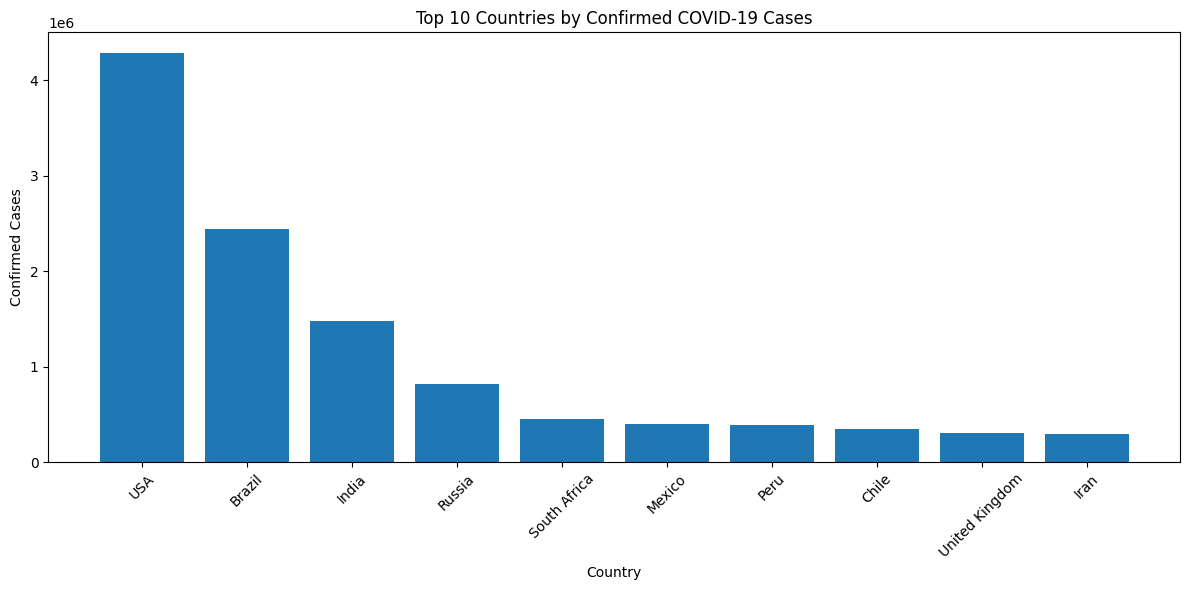

In [12]:
# Step 1 : Select Required Columnn
df_confirmed_cases = df_country_wise_latest.select(
    "Country/Region",
    "Confirmed"
)

# Step 2 : Sort Countries by Confirmed Cases
df_top_confirmed_cases = (
    df_confirmed_cases
    .orderBy(
        desc("Confirmed")
    )
)

# Step 3 : Extract Top 10 Countries
df_top_10_confirmed_cases = (
    df_top_confirmed_cases
    .limit(10)
)

# Step 4 : Convert to Pandas DataFrame
df_top_10_confirmed_cases_pandas = (
    df_top_10_confirmed_cases.toPandas()
)

df_top_10_confirmed_cases.show(truncate=False)

# Step 5 : Bar Chart Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(
    df_top_10_confirmed_cases_pandas["Country/Region"],
    df_top_10_confirmed_cases_pandas["Confirmed"]
)
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.tight_layout()
plt.show()

#### **Task 6** : Top 10 Countries by Death Rate


Country                             Deaths      Confirmed   Death Rate %
Yemen                                  483          1,691          28.56
United Kingdom                      45,844        301,708          15.19
Belgium                              9,822         66,428          14.79
Italy                               35,112        246,286          14.26
France                              30,212        220,352          13.71
Hungary                                596          4,448           13.4
Netherlands                          6,160         53,413          11.53
Mexico                              44,022        395,489          11.13
Spain                               28,432        272,421          10.44
Western Sahara                           1             10           10.0


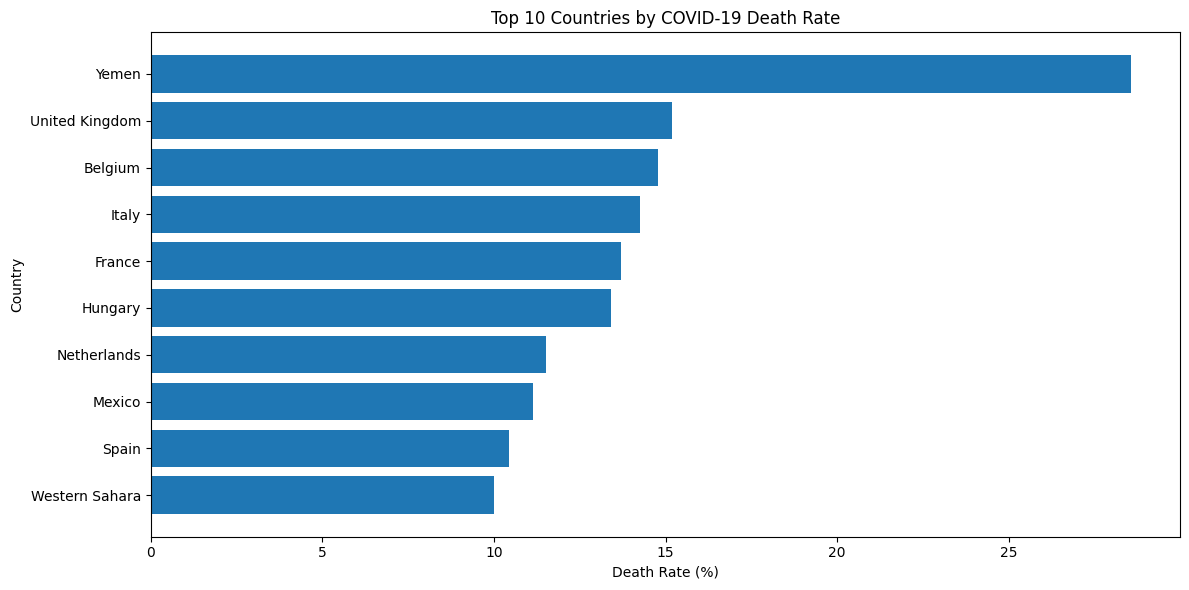

In [13]:
# Step 1 : Select Required Columns
df_death_rate = df_country_wise_latest.select(
    "Country/Region",
    "Deaths",
    "Confirmed"
)

# Step 2 : Calculate Death Rate
df_death_rate = (df_death_rate.withColumn("Death Rate",round((col("Deaths") / col("Confirmed")) * 100,2)))

# Step 3 : Sort by Death Rate
df_death_rate_sorted = (df_death_rate.orderBy(desc("Death Rate")))

# Step 4 : Extract Top 10 Countries
df_top_10_death_rate = (df_death_rate_sorted.limit(10))

# Step 5 : Display Final Output
print("=" * 75)
print(f"{'Country':<30}{'Deaths':>12}{'Confirmed':>15}{'Death Rate %':>15}")
print("=" * 75)
for row in df_top_10_death_rate.collect():
    print(f"{row['Country/Region']:<30}{row['Deaths']:>12,}{row['Confirmed']:>15,}{row['Death Rate']:>15}")
print("=" * 75)

# Convert to Pandas
df_top_10_death_rate_pandas = (
    df_top_10_death_rate.toPandas()
)

# Visualization : Top 10 Death Rate Countries
plt.figure(figsize=(12, 6))
plt.barh(
    df_top_10_death_rate_pandas["Country/Region"],
    df_top_10_death_rate_pandas["Death Rate"]
)
plt.xlabel("Death Rate (%)")
plt.ylabel("Country")
plt.title("Top 10 Countries by COVID-19 Death Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### **Task 7** : WHO Region-wise Total Cases


In [14]:
# Step 1 : Group by WHO Region
df_who_region_cases = (
    df_full_grouped
    .groupBy("WHO Region")
    .agg(
        sum("Confirmed").alias("Total Confirmed"),
        sum("Deaths").alias("Total Deaths"),
        sum("Recovered").alias("Total Recovered")
    )
)

# Step 2 : Sort by Total Confirmed Cases
df_who_region_cases = df_who_region_cases.orderBy(col("Total Confirmed").desc())

# Step 4 : Convert to Pandas DataFrame
df_who_region_cases_pandas = (
    df_who_region_cases.toPandas()
)

In [15]:
df_who_region_cases_pandas

,WHO Region,Total Confirmed,Total Deaths,Total Recovered
0,Americas,402261194,19359292,157069444
1,Europe,248879793,19271040,123202075
2,Eastern Mediterranean,74082892,1924029,48050703
3,South-East Asia,55118365,1458134,30030327
4,Western Pacific,26374411,932430,18861950
5,Africa,21791827,439978,11193730


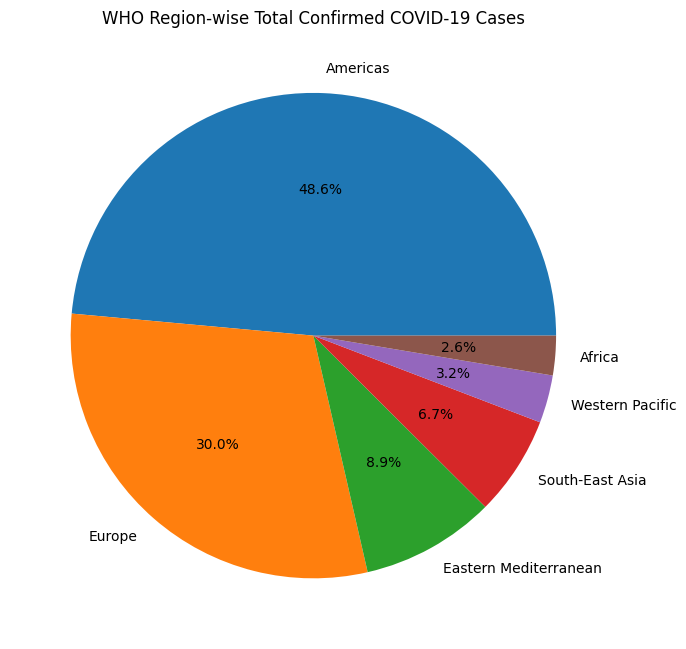

In [16]:
# Step 5 : Pie Chart Visualization : Total Confirmed Cases by WHO Region
plt.figure(figsize=(7, 7))
plt.pie(
    df_who_region_cases_pandas["Total Confirmed"],
    labels=df_who_region_cases_pandas["WHO Region"],
    autopct="%1.1f%%"
)
plt.title("WHO Region-wise Total Confirmed COVID-19 Cases")
plt.tight_layout()
plt.show()

## **Module 4** : Time-Series Analysis


#### **Task 8** : Daily Global New Cases Trend


In [17]:
df_day_wise.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- Deaths / 100 Cases: double (nullable = true)
 |-- Recovered / 100 Cases: double (nullable = true)
 |-- Deaths / 100 Recovered: double (nullable = true)
 |-- No. of countries: integer (nullable = true)



In [18]:
# Select Required Columns
daily_cases_df = df_day_wise.select(
    "Date",
    "New cases"
)

# Convert Spark DataFrame to Pandas (Needed for matplotlib visualization)

daily_cases_pd = daily_cases_df.toPandas()
daily_cases_pd.head()

,Date,New cases
0,2020-01-22,0
1,2020-01-23,99
2,2020-01-24,287
3,2020-01-25,493
4,2020-01-26,684


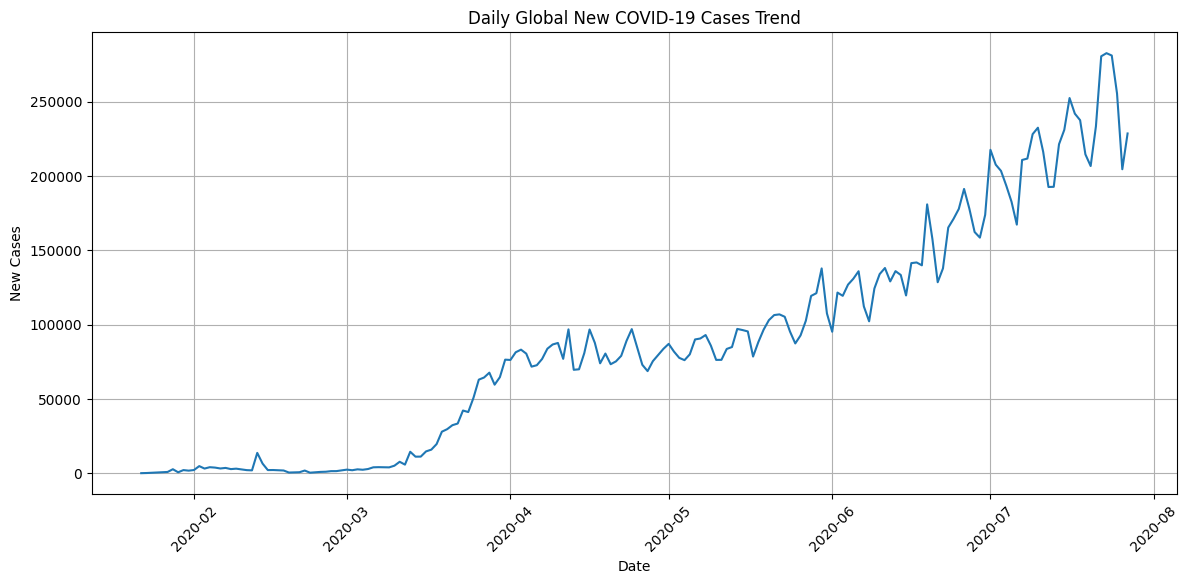

In [19]:
# Plot : Daily Global New Cases Trend
plt.figure(figsize=(14,6))
plt.plot(
    daily_cases_pd["Date"],
    daily_cases_pd["New cases"]
)
plt.title("Daily Global New COVID-19 Cases Trend")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### **Task 9** : Daily Global Death Growth Trend


In [20]:
from pyspark.sql.window import Window
import pandas as pd

In [21]:
# display schema
df_day_wise.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- Deaths / 100 Cases: double (nullable = true)
 |-- Recovered / 100 Cases: double (nullable = true)
 |-- Deaths / 100 Recovered: double (nullable = true)
 |-- No. of countries: integer (nullable = true)



In [22]:
# Select Required Columns
death_growth_df = df_day_wise.select(
    "Date",
    "New deaths"
)
death_growth_df.show(10, truncate=False)

# Create Window Specification
window_spec = Window.orderBy("Date")

+----------+----------+
|Date      |New deaths|
+----------+----------+
|2020-01-22|0         |
|2020-01-23|1         |
|2020-01-24|8         |
|2020-01-25|16        |
|2020-01-26|14        |
|2020-01-27|26        |
|2020-01-28|49        |
|2020-01-29|2         |
|2020-01-30|38        |
|2020-01-31|42        |
+----------+----------+
only showing top 10 rows


In [23]:
# Get Previous Day Deaths using lag()
death_growth_df = death_growth_df.withColumn(
    "Previous Day Deaths",
    lag("New deaths", 1).over(window_spec)
)
death_growth_df.show(10, truncate=False)

+----------+----------+-------------------+
|Date      |New deaths|Previous Day Deaths|
+----------+----------+-------------------+
|2020-01-22|0         |NULL               |
|2020-01-23|1         |0                  |
|2020-01-24|8         |1                  |
|2020-01-25|16        |8                  |
|2020-01-26|14        |16                 |
|2020-01-27|26        |14                 |
|2020-01-28|49        |26                 |
|2020-01-29|2         |49                 |
|2020-01-30|38        |2                  |
|2020-01-31|42        |38                 |
+----------+----------+-------------------+
only showing top 10 rows


In [24]:
# Calculate Daily Death Growth Percentage
death_growth_df = death_growth_df.withColumn(
    "Death Growth %",
    
    when(
        (col("Previous Day Deaths").isNull()) |
        (col("Previous Day Deaths") == 0),
        None
    ).otherwise(
        (
            col("New deaths") /
            col("Previous Day Deaths")
        ) * 100
    )
)

death_growth_df.show(10, truncate=False)

+----------+----------+-------------------+------------------+
|Date      |New deaths|Previous Day Deaths|Death Growth %    |
+----------+----------+-------------------+------------------+
|2020-01-22|0         |NULL               |NULL              |
|2020-01-23|1         |0                  |NULL              |
|2020-01-24|8         |1                  |800.0             |
|2020-01-25|16        |8                  |200.0             |
|2020-01-26|14        |16                 |87.5              |
|2020-01-27|26        |14                 |185.71428571428572|
|2020-01-28|49        |26                 |188.46153846153845|
|2020-01-29|2         |49                 |4.081632653061225 |
|2020-01-30|38        |2                  |1900.0            |
|2020-01-31|42        |38                 |110.5263157894737 |
+----------+----------+-------------------+------------------+
only showing top 10 rows


In [25]:
# Convert to Pandas for Visualization
death_growth_pd = death_growth_df.toPandas()

# Convert Date Column to Datetime
death_growth_pd["Date"] = pd.to_datetime(
    death_growth_pd["Date"]
)

death_growth_pd.head()

,Date,New deaths,Previous Day Deaths,Death Growth %
0,2020-01-22,0,NaN,NaN
1,2020-01-23,1,0.0,NaN
2,2020-01-24,8,1.0,800.0
3,2020-01-25,16,8.0,200.0
4,2020-01-26,14,16.0,87.5


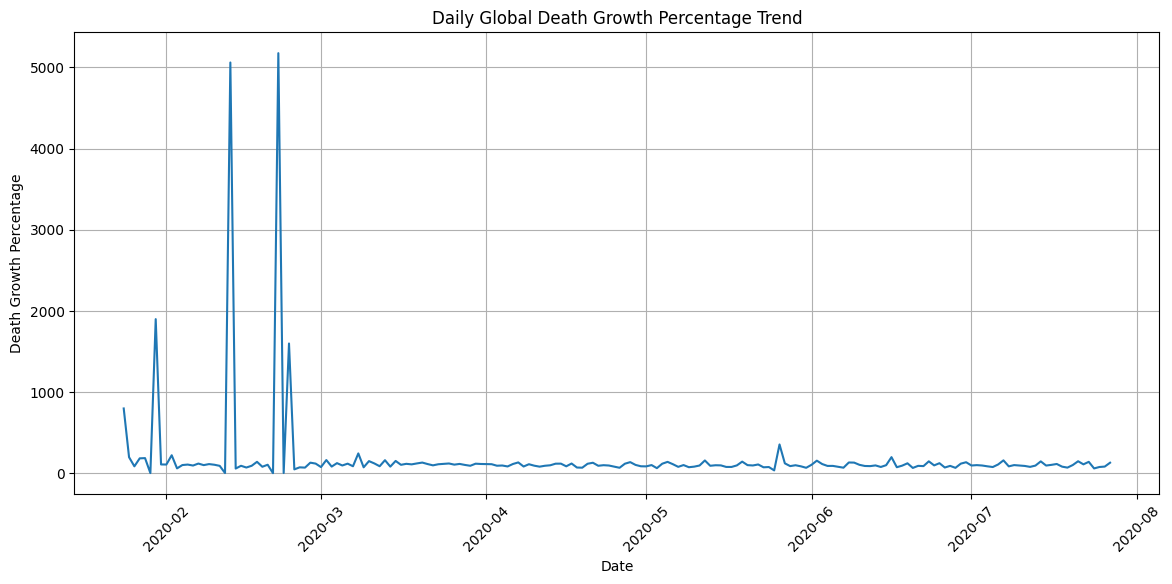

In [26]:
# Plot : Daily Global Death Growth Trend
plt.figure(figsize=(14,6))

plt.plot(
    death_growth_pd["Date"],
    death_growth_pd["Death Growth %"]
)

plt.title("Daily Global Death Growth Percentage Trend")
plt.xlabel("Date")
plt.ylabel("Death Growth Percentage")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### **Task 10** : Monthly COVID Case Growth


In [27]:
# Display Schema
df_full_grouped.printSchema()

# Convert Date Column to Proper Date Type
df_full_grouped = df_full_grouped.withColumn(
    "Date",
    to_date(col("Date"), "yyyy-MM-dd")
)

root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)



In [28]:
# Extract Month from Original DataFrame
monthly_cases_df = df_full_grouped.withColumn(
    "Month",
    month(col("Date"))
)

monthly_cases_df.select(
    "Date",
    "Month",
    "Confirmed"
).show(10, truncate=False)

+----------+-----+---------+
|Date      |Month|Confirmed|
+----------+-----+---------+
|2020-01-22|1    |0        |
|2020-01-22|1    |0        |
|2020-01-22|1    |0        |
|2020-01-22|1    |0        |
|2020-01-22|1    |0        |
|2020-01-22|1    |0        |
|2020-01-22|1    |0        |
|2020-01-22|1    |0        |
|2020-01-22|1    |0        |
|2020-01-22|1    |0        |
+----------+-----+---------+
only showing top 10 rows


In [29]:
# Group By Month and Calculate Total Cases
monthly_cases_summary = (
    monthly_cases_df
    .groupBy("Month")
    .agg(
        sum("Confirmed").alias("Total Confirmed Cases")
    )
    .orderBy("Month")
)

# Show Output
monthly_cases_summary.show(truncate=False)

# Convert to Pandas
monthly_cases_pd = monthly_cases_summary.toPandas()
monthly_cases_pd.head()


+-----+---------------------+
|Month|Total Confirmed Cases|
+-----+---------------------+
|1    |38534                |
|2    |1663437              |
|3    |9002815              |
|4    |63391662             |
|5    |144990399            |
|6    |246525787            |
|7    |362895848            |
+-----+---------------------+



,Month,Total Confirmed Cases
0,1,38534
1,2,1663437
2,3,9002815
3,4,63391662
4,5,144990399


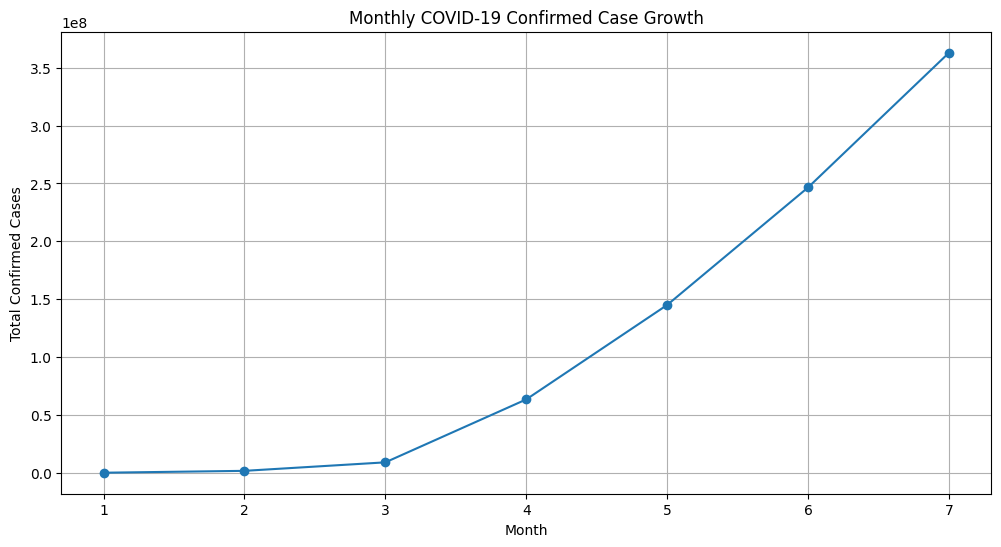

In [30]:
# Plot : Monthly COVID Case Growth Trend
plt.figure(figsize=(12,6))
plt.plot(
    monthly_cases_pd["Month"],
    monthly_cases_pd["Total Confirmed Cases"],
    marker='o'
)
plt.title("Monthly COVID-19 Confirmed Case Growth")
plt.xlabel("Month")
plt.ylabel("Total Confirmed Cases")
plt.xticks(monthly_cases_pd["Month"])
plt.grid(True)
plt.show()

## **Module 5** : Window Function Tasks


#### **Task 11** : Top 5 Most Affected Countries Per WHO Region


In [ ]:
# Creating Window Specification 
window_spec_who = Window.partitionBy("WHO Region").orderBy(col("Confirmed").desc())

# dense_rank() metric
df_ranked_who_region = df_country_wise_latest.withColumn(
    "Rank",
    dense_rank().over(window_spec_who)
)

# Filtering the Top 5 Most Affected Countries
df_top_5_who_region = df_ranked_who_region.filter(col("Rank") <= 5)

# Display the output
df_top_5_who_region.select(
    "WHO Region", 
    "Country/Region", 
    "Confirmed", 
    "Rank"
).show(30, truncate=False)

+---------------------+--------------+---------+----+
|WHO Region           |Country/Region|Confirmed|Rank|
+---------------------+--------------+---------+----+
|Africa               |South Africa  |452529   |1   |
|Africa               |Nigeria       |41180    |2   |
|Africa               |Ghana         |33624    |3   |
|Africa               |Algeria       |27973    |4   |
|Africa               |Kenya         |17975    |5   |
|Americas             |USA           |4290259  |1   |
|Americas             |Brazil        |2442375  |2   |
|Americas             |Mexico        |395489   |3   |
|Americas             |Peru          |389717   |4   |
|Americas             |Chile         |347923   |5   |
|Eastern Mediterranean|Iran          |293606   |1   |
|Eastern Mediterranean|Pakistan      |274289   |2   |
|Eastern Mediterranean|Saudi Arabia  |268934   |3   |
|Eastern Mediterranean|Iraq          |112585   |4   |
|Eastern Mediterranean|Qatar         |109597   |5   |
|Europe               |Russi

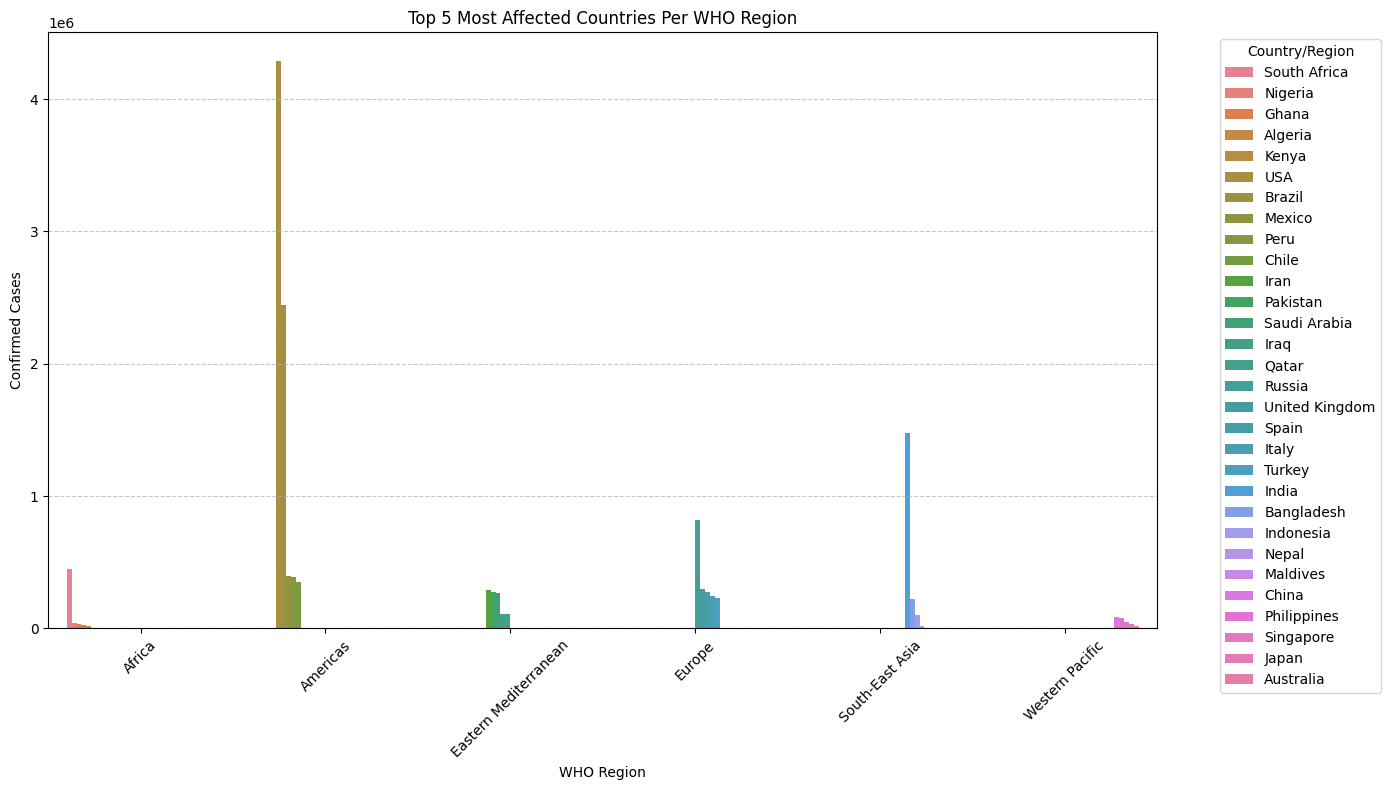

In [32]:
import seaborn as sns

# Convert the resulting PySpark DataFrame to a Pandas DataFrame for visualization
df_top_5_who_region_pd = df_top_5_who_region.toPandas()

# grouped bar chart 
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_top_5_who_region_pd,
    x="WHO Region",
    y="Confirmed",
    hue="Country/Region",
    dodge=True
)

plt.title("Top 5 Most Affected Countries Per WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.legend(title="Country/Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### **Task 12** : Country-wise Daily Case Increase


In [33]:
# Create Window Specification
window_spec_country = Window.partitionBy("Country/Region").orderBy("Date")

# previous day confirmed using lag()
df_country_daily_increase = df_full_grouped.withColumn(
    "Previous Day Confirmed",
    lag("Confirmed", 1).over(window_spec_country)
)

# Calculating daily case increase (today - yesterday)
df_country_daily_increase = df_country_daily_increase.withColumn(
    "Calculated New Cases",
    when(col("Previous Day Confirmed").isNull(), 0)
    .otherwise(col("Confirmed") - col("Previous Day Confirmed"))
)

# Displaying result for verifying
df_country_daily_increase.filter(col("Country/Region") == "USA").select(
    "Date", "Country/Region", "Confirmed", "Previous Day Confirmed", "Calculated New Cases"
).show(10, truncate=False)

+----------+--------------+---------+----------------------+--------------------+
|Date      |Country/Region|Confirmed|Previous Day Confirmed|Calculated New Cases|
+----------+--------------+---------+----------------------+--------------------+
|2020-01-22|USA           |1        |NULL                  |0                   |
|2020-01-23|USA           |1        |1                     |0                   |
|2020-01-24|USA           |2        |1                     |1                   |
|2020-01-25|USA           |2        |2                     |0                   |
|2020-01-26|USA           |5        |2                     |3                   |
|2020-01-27|USA           |5        |5                     |0                   |
|2020-01-28|USA           |5        |5                     |0                   |
|2020-01-29|USA           |5        |5                     |0                   |
|2020-01-30|USA           |5        |5                     |0                   |
|2020-01-31|USA 

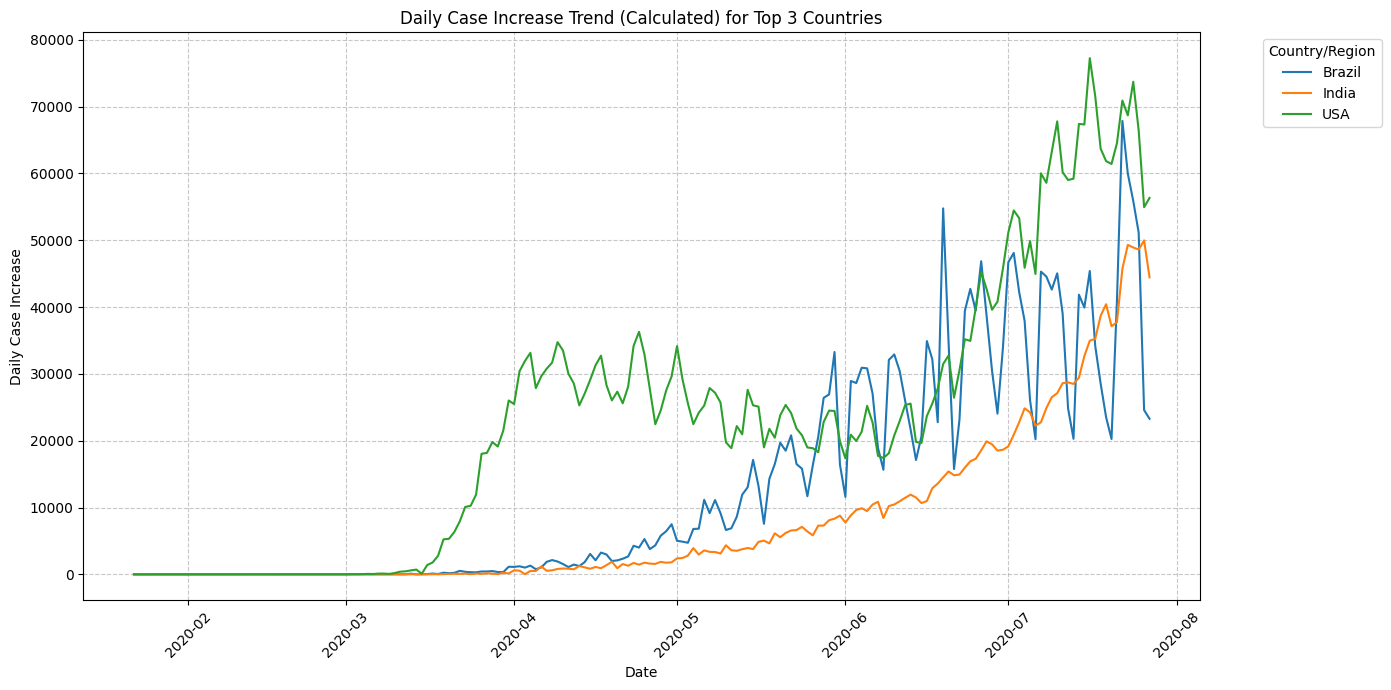

In [34]:
# for visualization
top_3_countries = ["India", "Brazil", "USA"]

df_trend_filtered = df_country_daily_increase.filter(
    col("Country/Region").isin(top_3_countries)
)

# converting ot pandas for visualization
df_trend_pd = df_trend_filtered.select("Date", "Country/Region", "Calculated New Cases").toPandas()

# Country Trend Chart
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_trend_pd,
    x="Date",
    y="Calculated New Cases",
    hue="Country/Region"
)

plt.title("Daily Case Increase Trend (Calculated) for Top 3 Countries")
plt.xlabel("Date")
plt.ylabel("Daily Case Increase")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Country/Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Module 6**: Join Operations


#### **Task 13** : Compare Latest Dataset Sources


In [ ]:
# selecting and rename columns from country_wise_latest
df_cwl_subset = df_country_wise_latest.select(
    col("Country/Region"),
    col("Confirmed").alias("CWL_Confirmed"),
    col("Deaths").alias("CWL_Deaths"),
    col("Recovered").alias("CWL_Recovered")
)

# selecting and rename columns from worldometer_data
df_world_subset = df_worldometer_data.select(
    col("Country/Region"),
    col("TotalCases").alias("World_Confirmed"),
    col("TotalDeaths").alias("World_Deaths"),
    col("TotalRecovered").alias("World_Recovered")
)

# join datasets on Country/Region
df_joined_compare = df_cwl_subset.join(
    df_world_subset,
    on="Country/Region",
    how="inner"
)

# calculate differences
df_mismatch_analysis = df_joined_compare.withColumn(
    "Confirmed_Diff", abs(col("CWL_Confirmed") - col("World_Confirmed"))
).withColumn(
    "Death_Diff", abs(col("CWL_Deaths") - col("World_Deaths"))
).withColumn(
    "Recovered_Diff", abs(col("CWL_Recovered") - col("World_Recovered"))
)

# filter and sort to find large mismatches
# assuming a large mismatch in Confirmed cases is greater than 10,000 for example,
# ordering by the largest mismatch first.
df_large_mismatches = (
    df_mismatch_analysis
    .filter((col("Confirmed_Diff") > 10000) | (col("Death_Diff") > 1000) | (col("Recovered_Diff") > 10000))
    .orderBy(desc("Confirmed_Diff"))
)

# Display Output
df_large_mismatches.select(
    "Country/Region", 
    "Confirmed_Diff", 
    "Death_Diff", 
    "Recovered_Diff"
).show(15, truncate=False)

+--------------+--------------+----------+--------------+
|Country/Region|Confirmed_Diff|Death_Diff|Recovered_Diff|
+--------------+--------------+----------+--------------+
|USA           |741920        |14793     |1250864       |
|India         |545336        |8230      |426218        |
|Brazil        |475187        |11026     |201019        |
|Colombia      |100609        |3162      |61194         |
|South Africa  |85655         |2537      |112391        |
|Spain         |82109         |68        |NULL          |
|Mexico        |67201         |6495      |5038          |
|Peru          |65692         |2006      |37790         |
|Argentina     |60779         |1192      |27277         |
|Russia        |55214         |1272      |74108         |
|Philippines   |37420         |205       |40391         |
|Iraq          |28018         |703       |23881         |
|Iran          |26511         |2064      |22319         |
|France        |24719         |100       |1248          |
|Bangladesh   

#### **Task 14** : Population vs Total Cases


In [36]:
# Filter data to ensure Population is valid and calculate Infection Rate
df_infection_rate = df_worldometer_data.filter(
    col("Population").isNotNull() & (col("Population") > 0)
).withColumn(
    "Infection Rate (%)",
    round((col("TotalCases") / col("Population")) * 100, 2)
)

# Get the top 15 countries with the highest infection rate
df_top_infection = df_infection_rate.orderBy(desc("Infection Rate (%)")).limit(15)

# Display the calculated metrics
df_top_infection.select(
    "Country/Region", 
    "Population", 
    "TotalCases", 
    "Infection Rate (%)"
).show(15, truncate=False)

+--------------+----------+----------+------------------+
|Country/Region|Population|TotalCases|Infection Rate (%)|
+--------------+----------+----------+------------------+
|Qatar         |2807805   |112092    |3.99              |
|French Guiana |299385    |8127      |2.71              |
|Bahrain       |1706669   |42889     |2.51              |
|San Marino    |33938     |699       |2.06              |
|Chile         |19132514  |366671    |1.92              |
|Panama        |4321282   |71418     |1.65              |
|Kuwait        |4276658   |70045     |1.64              |
|Oman          |5118446   |80713     |1.58              |
|USA           |331198130 |5032179   |1.52              |
|Vatican City  |801       |12        |1.5               |
|Peru          |33016319  |455409    |1.38              |
|Brazil        |212710692 |2917562   |1.37              |
|Armenia       |2963811   |39819     |1.34              |
|Andorra       |77278     |944       |1.22              |
|Luxembourg   

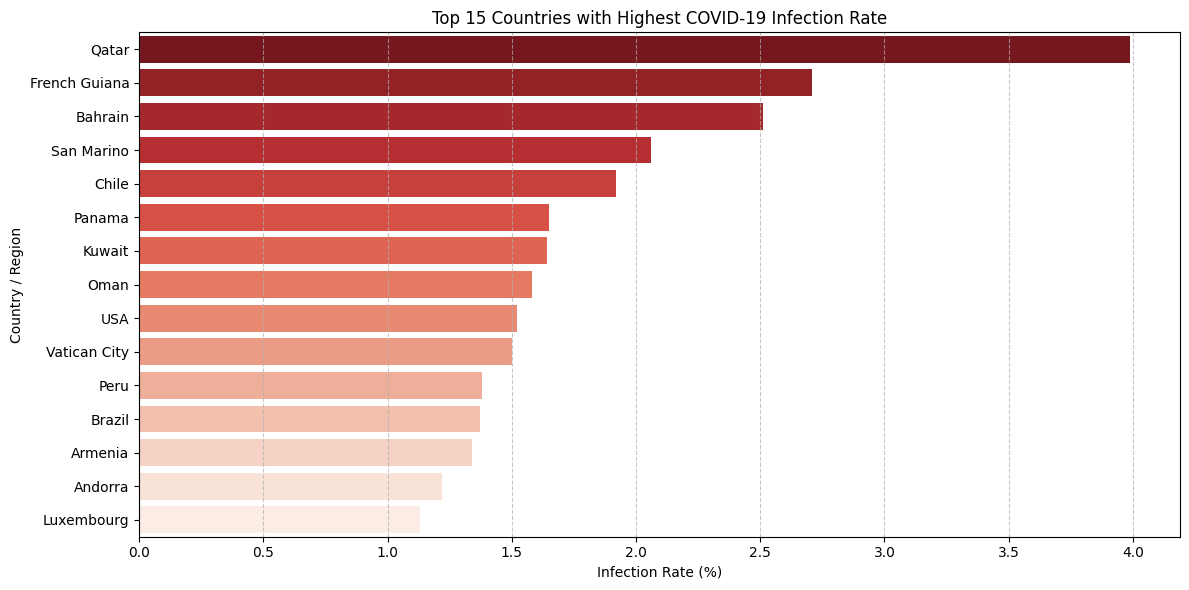

In [37]:
# Convert to Pandas for visualization
df_top_infection_pd = df_top_infection.toPandas()

# Bar Chart for Highest Infection Rates
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_top_infection_pd,
    x="Infection Rate (%)",
    y="Country/Region",
    palette="Reds_r",
    hue="Country/Region",
    legend=False
)

plt.title("Top 15 Countries with Highest COVID-19 Infection Rate")
plt.xlabel("Infection Rate (%)")
plt.ylabel("Country / Region")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

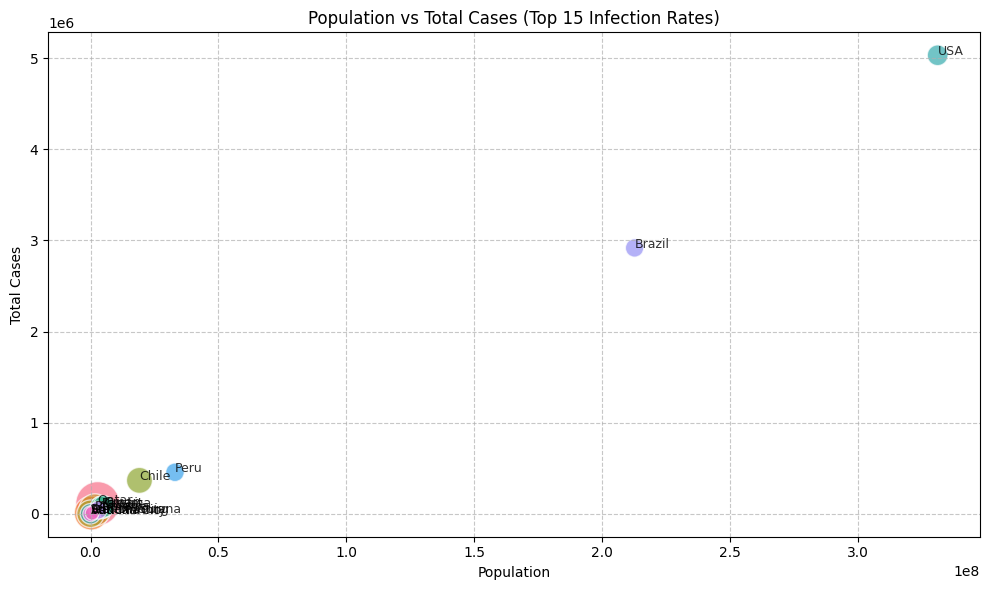

In [ ]:
# Scatter plot of Population vs Total Cases for the top 15
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_top_infection_pd,
    x="Population",
    y="TotalCases",
    size="Infection Rate (%)",
    sizes=(100, 1000),
    hue="Country/Region",
    alpha=0.7,
    legend=False
)

# adding labels
for i in range(df_top_infection_pd.shape[0]):
    plt.text(
        df_top_infection_pd["Population"][i], 
        df_top_infection_pd["TotalCases"][i], 
        df_top_infection_pd["Country/Region"][i], 
        fontsize=9, alpha=0.8
    )

plt.title("Population vs Total Cases (Top 15 Infection Rates)")
plt.xlabel("Population")
plt.ylabel("Total Cases")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Module 7** : Geographic Analysis

#### **Task 15**: USA State-wise Case Distribution


In [39]:
# Filter out null counties, group by state, and count
df_state_county_count = df_usa_county_wise.filter(
    col("Admin2").isNotNull() & (col("Admin2") != "Unassigned")
).groupBy("Province_State").agg(
    count("Admin2").alias("County Count")
)

# Sort by number of counties in descending order
df_state_county_count = df_state_county_count.orderBy(desc("County Count"))

# Display the top 20 states
df_state_county_count.show(20, truncate=False)

+--------------+------------+
|Province_State|County Count|
+--------------+------------+
|Texas         |47940       |
|Georgia       |30080       |
|Virginia      |25192       |
|Kentucky      |22748       |
|Missouri      |21996       |
|Kansas        |19928       |
|Illinois      |19364       |
|North Carolina|18988       |
|Iowa          |18800       |
|Tennessee     |18048       |
|Nebraska      |17672       |
|Indiana       |17484       |
|Ohio          |16732       |
|Minnesota     |16544       |
|Michigan      |16168       |
|Mississippi   |15604       |
|Puerto Rico   |14852       |
|Oklahoma      |14664       |
|Arkansas      |14288       |
|Wisconsin     |13724       |
+--------------+------------+
only showing top 20 rows


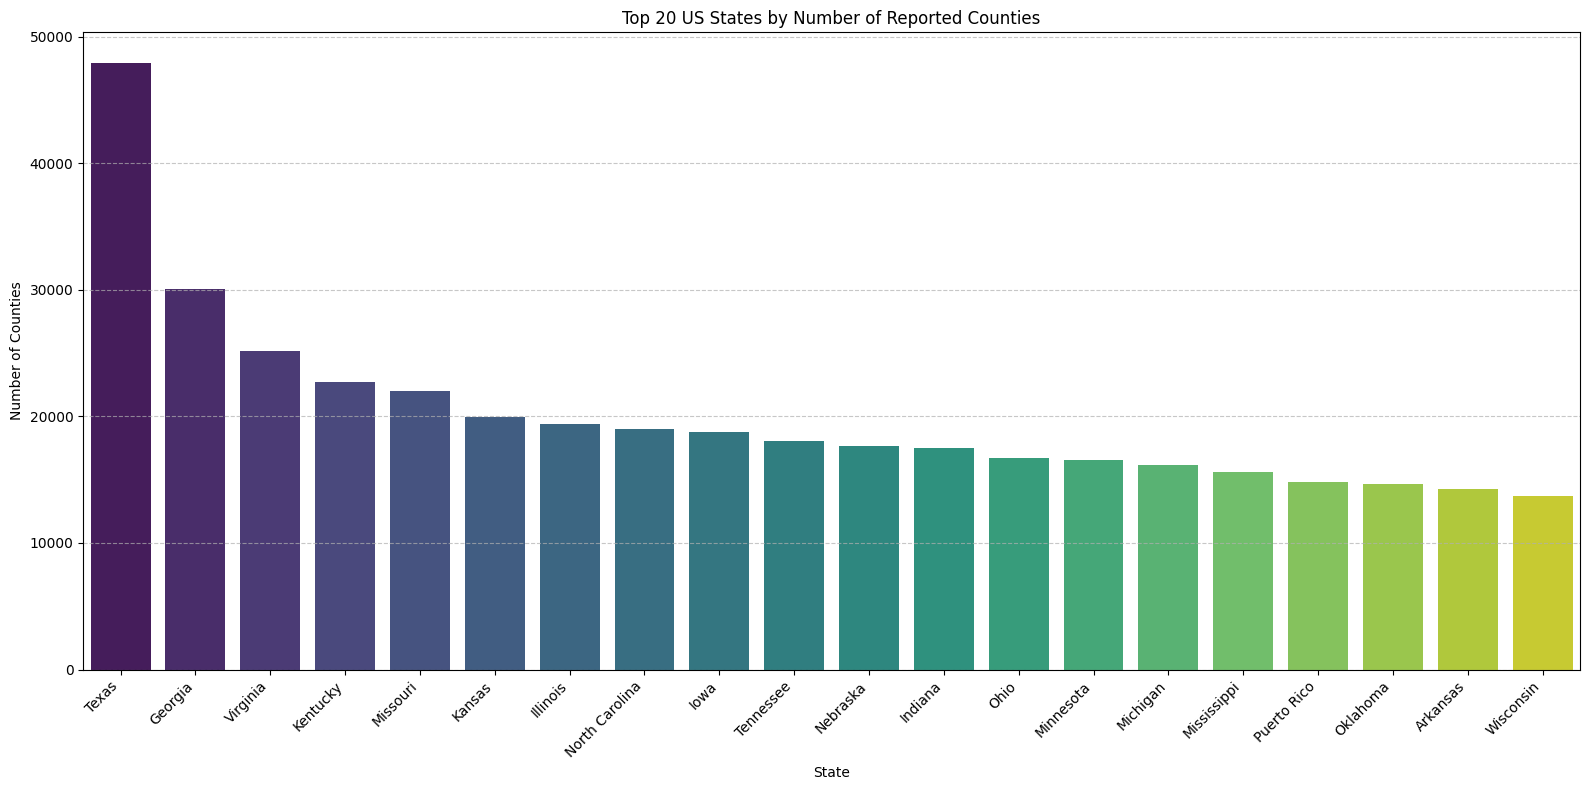

In [40]:


# Convert to Pandas DataFrame for visualization
df_state_county_pd = df_state_county_count.toPandas()

# Plot: Bar Chart 
plt.figure(figsize=(16, 8))
sns.barplot(
    data=df_state_county_pd.head(20), 
    x="Province_State",
    y="County Count",
    palette="viridis",
    hue="Province_State",
    legend=False
)

plt.title("Top 20 US States by Number of Reported Counties")
plt.xlabel("State")
plt.ylabel("Number of Counties")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### **Task 16** : Latitude-Longitude Based Case Clusters


In [41]:
# Group by Latitude and Longitude
df_geo_clusters = df_covid_19_clean_complete.filter(
    col("Lat").isNotNull() & col("Long").isNotNull()
).groupBy(
    "Lat", 
    "Long"
).agg(
    max("Confirmed").alias("Total Confirmed")
)

# Filter out locations with zero cases
df_geo_clusters = df_geo_clusters.filter(col("Total Confirmed") > 0)

# Display the output dataset
df_geo_clusters.show(15, truncate=False)

+---------+-----------------+---------------+
|Lat      |Long             |Total Confirmed|
+---------+-----------------+---------------+
|37.2692  |106.1655         |75             |
|-1.8312  |-78.1834         |81161          |
|17.9     |-62.8333         |7              |
|48.669   |19.699           |2181           |
|32.427908|53.68804599999999|293606         |
|33.886917|9.537499         |1455           |
|40.1431  |47.5769          |30446          |
|9.9456   |-9.6966          |7055           |
|41.9029  |12.4534          |12             |
|21.0079  |-10.9408         |6208           |
|18.2206  |-63.0686         |3              |
|3.9193   |-56.0278         |1483           |
|-11.2027 |17.8739          |950            |
|7.54     |-5.5471          |15655          |
|17.607789|8.081666         |1136           |
+---------+-----------------+---------------+
only showing top 15 rows


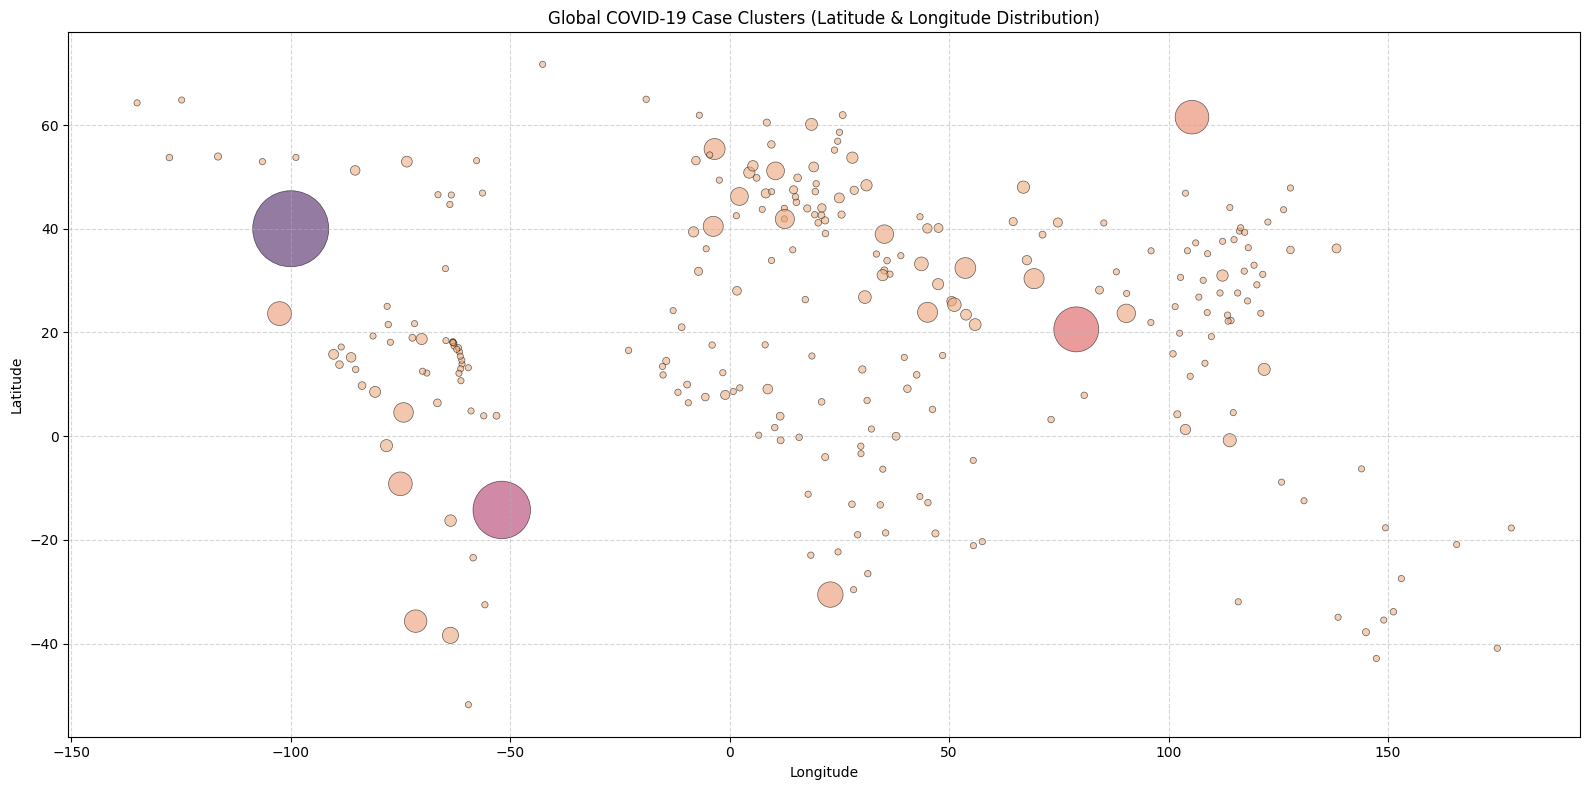

In [ ]:
# Convert the DataFrame to Pandas 
df_geo_pd = df_geo_clusters.toPandas()

# Plot: Geo Scatter Plot
plt.figure(figsize=(16, 8))

sns.scatterplot(
    data=df_geo_pd,
    x="Long",
    y="Lat",
    size="Total Confirmed",
    sizes=(20, 3000),  
    hue="Total Confirmed",
    palette="flare",   
    alpha=0.6,
    edgecolor="black",
    linewidth=0.5,
    legend=False
)

plt.title("Global COVID-19 Case Clusters (Latitude & Longitude Distribution)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()